<a href="https://colab.research.google.com/github/cesarjuarez72/a15_cesar_juarez_intro_ai_course_the_final/blob/main/a15_intro_ai_the_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Resources & Links:**
* **GitHub Repository:** [Open in GitHub](https://github.com/cesarjuarez72/a15_cesar_juarez_intro_ai_course_the_final.git)
* **Google Colab Notebook:** [Open in Google Colab](https://colab.research.google.com/drive/1ihyQNZkeLTqU7hXvCLh38JKm4MbZO5Zz?usp=sharing)


# 🎵 Music Learner Telemetry Diagnostic System
### Machine Learning Classification & Interactive Deployment Pipeline

* **Author:** Cesar Juarez
* **Date:** September 17, 2026
* **Environment:** Python 3 | Scikit-Learn | Google Colab

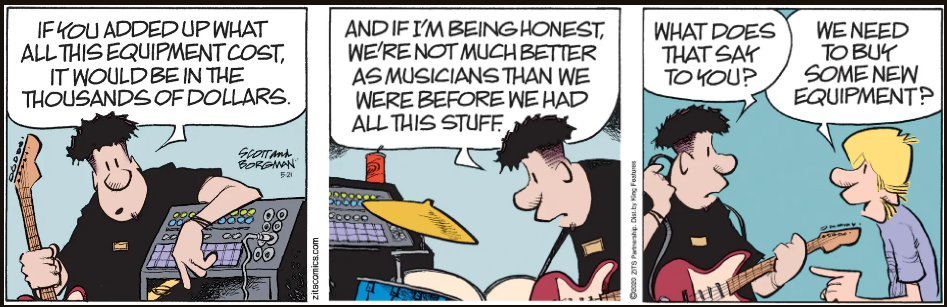

# 🎵 Stage 1: Problem Definition & Data Ingestion

### What We Are Solving
Learning an instrument takes hundreds of hours of deliberate practice. One major reason learners drop out is pacing: exercises that are too difficult cause frustration, while material that is too easy leads to boredom.

The goal of this project is to build an automated diagnostic classifier that analyzes session practice telemetry (pitch accuracy, rhythm precision, tempo stability, and musical expressiveness) to predict a student's actual operational skill tier: `Beginner`, `Intermediate`, or `Advanced`. This enables an adaptive music platform to automatically tune exercise difficulty and recommend targeted practice routines without requiring a human instructor to grade every session.

---

### The Dataset
We are using the **Music Learner Performance Dataset** (`music_learners_dataset.csv`), containing 2,000 practice session records:
* **Identifiers:** `learner_id`, `session_id` (administrative tags, excluded from model training).
* **Learner Context:** `age`, `instrument` (Piano, Guitar, Violin, Drums, Flute).
* **Practice Habits:** `practice_duration` (session length in minutes).
* **Performance Telemetry:** `tempo_accuracy`, `pitch_accuracy`, `rhythm_accuracy` (percentages 50–100%), and `expressiveness_score` (scale 1–10).
* **Target Variable:** `skill_level` (`Beginner`, `Intermediate`, `Advanced`).

---

### How the Ingestion Works
The code verifies that the dataset exists locally or in Google Colab's workspace. It checks row and column dimensions, validates column data types, and displays a quick summary of the data structure.

In [4]:
import os
import sys
import warnings
import numpy as np
import pandas as pd

# Suppress unnecessary runtime warnings
warnings.filterwarnings("ignore")

DATASET_NAME = "music_learners_dataset.csv"

def load_dataset(file_path: str) -> pd.DataFrame:
    """
    Validates file existence and loads the music learner performance dataset.
    Raises FileNotFoundError with clear instructions if missing.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Dataset '{file_path}' not found. Please upload '{file_path}' "
            "to your Google Colab files panel or current working directory."
        )

    df = pd.read_csv(file_path)
    print(f"--> Dataset successfully loaded from: {file_path}")
    print(f"--> Total Rows: {df.shape[0]} | Total Features: {df.shape[1]}")
    return df

# Ingest and display initial summary
df_raw = load_dataset(DATASET_NAME)
print("\nFeature Schema & Data Types:")
print(df_raw.dtypes)
print("\nFirst 3 Records:")
df_raw.head(3)

--> Dataset successfully loaded from: music_learners_dataset.csv
--> Total Rows: 2000 | Total Features: 10

Feature Schema & Data Types:
learner_id              object
session_id              object
age                      int64
instrument              object
practice_duration        int64
tempo_accuracy           int64
pitch_accuracy           int64
rhythm_accuracy          int64
expressiveness_score     int64
skill_level             object
dtype: object

First 3 Records:


,learner_id,session_id,age,instrument,practice_duration,tempo_accuracy,pitch_accuracy,rhythm_accuracy,expressiveness_score,skill_level
0,L087,S1696,17,Violin,22,87,62,60,7,Beginner
1,L469,S1737,36,Flute,106,90,71,63,4,Beginner
2,L485,S1950,24,Guitar,77,75,75,97,10,Advanced


# 🔍 Stage 2: Data Preprocessing & Exploratory Data Analysis (EDA)

### What We Are Doing
Before feeding data into machine learning algorithms, we need to inspect distributions, handle inconsistencies, encode categorical attributes, and normalize continuous measurements.

In this stage, we execute five key steps:
1. **Data Integrity & Missing Value Audit:** Check for null values, duplicates, and impossible numbers (e.g., negative practice times or accuracy over 100%).
2. **Exploratory Data Analysis (EDA):**
   * Inspect class distribution across `Beginner`, `Intermediate`, and `Advanced`.
   * Examine performance separation across acoustic telemetry metrics (Tempo, Pitch, and Rhythm Accuracy).
   * Evaluate `expressiveness_score` across skill tiers to understand feature importance.
3. **Feature Selection:** Drop identifier tags (`learner_id`, `session_id`) that carry no predictive signal.
4. **Encoding:**
   * Encode the target `skill_level` ordinally: `Beginner` $\rightarrow$ 0, `Intermediate` $\rightarrow$ 1, `Advanced` $\rightarrow$ 2.
   * One-hot encode the `instrument` column to allow linear and distance-based models to interpret categorical instruments without false ordinal bias.
5. **Stratified Split & Scaling:**
   * Split data into **80% training** and **20% testing** sets using stratified sampling to preserve the target class proportions.
   * Fit a `StandardScaler` strictly on the training set and transform the test set to eliminate data leakage.

--- 1. Data Hygiene Audit ---
Missing Values: 0
Duplicate Rows: 0


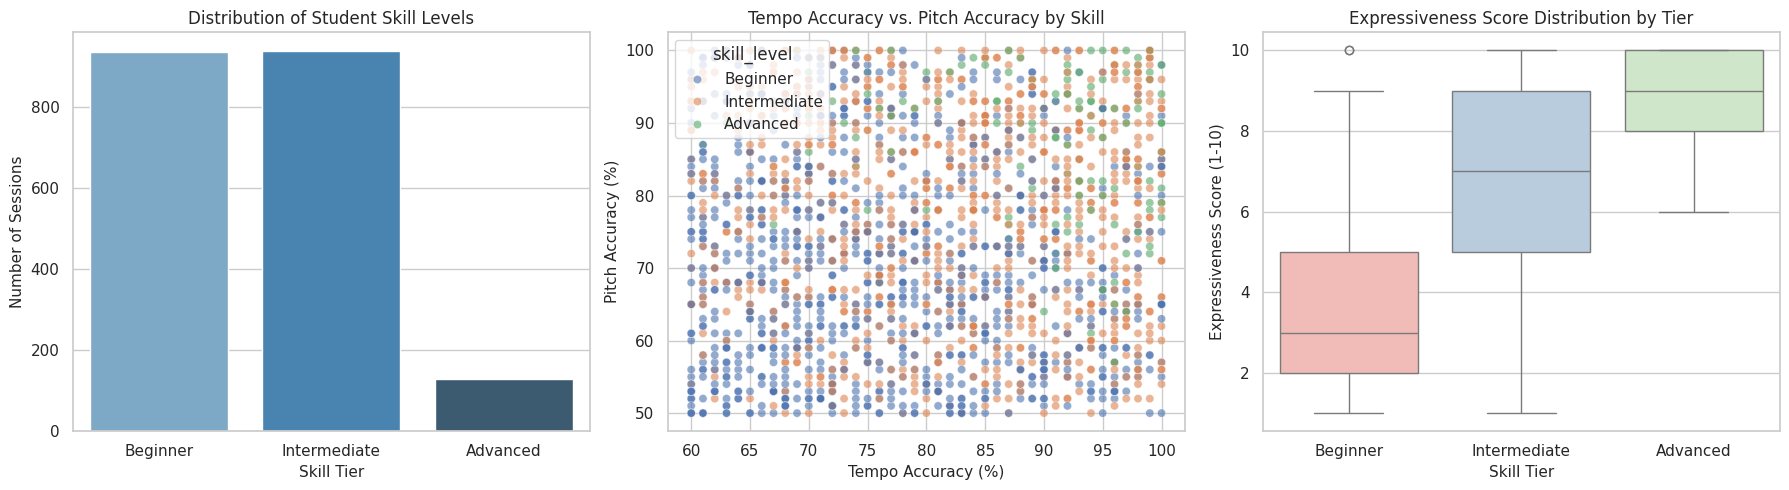


--- Preprocessing & Partitioning Summary ---
X_train Shape : (1600, 11) | y_train Shape: (1600,)
X_test Shape  : (400, 11)  | y_test Shape : (400,)
Target Class Proportions in Training Set:
skill_level_encoded
1    0.469
0    0.468
2    0.064
Name: proportion, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configure standard aesthetic settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 10, "axes.labelsize": 11, "figure.titlesize": 13})

df_clean = df_raw.copy()

# 1. Data Integrity and Hygiene Checks
print("--- 1. Data Hygiene Audit ---")
missing_per_col = df_clean.isnull().sum()
duplicate_rows = df_clean.duplicated().sum()

print(f"Missing Values: {missing_per_col.sum()}")
print(f"Duplicate Rows: {duplicate_rows}")

# Guard check: Ensure no empty records slipped through
if missing_per_col.sum() > 0:
    print("Notice: Imputing unexpected nulls with median values...")
    df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)

# 2. Exploratory Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Skill Level Balance
skill_order = ["Beginner", "Intermediate", "Advanced"]
sns.countplot(
    data=df_clean,
    x="skill_level",
    order=skill_order,
    palette="Blues_d",
    ax=axes[0]
)
axes[0].set_title("Distribution of Student Skill Levels")
axes[0].set_xlabel("Skill Tier")
axes[0].set_ylabel("Number of Sessions")

# Plot 2: Performance Telemetry (Tempo vs. Pitch Accuracy)
sns.scatterplot(
    data=df_clean,
    x="tempo_accuracy",
    y="pitch_accuracy",
    hue="skill_level",
    hue_order=skill_order,
    palette="deep",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Tempo Accuracy vs. Pitch Accuracy by Skill")
axes[1].set_xlabel("Tempo Accuracy (%)")
axes[1].set_ylabel("Pitch Accuracy (%)")

# Plot 3: Expressiveness Score across Skill Levels
sns.boxplot(
    data=df_clean,
    x="skill_level",
    y="expressiveness_score",
    order=skill_order,
    palette="Pastel1",
    ax=axes[2]
)
axes[2].set_title("Expressiveness Score Distribution by Tier")
axes[2].set_xlabel("Skill Tier")
axes[2].set_ylabel("Expressiveness Score (1-10)")

plt.tight_layout()
plt.show()

# 3. Feature Selection and Encoding
# Drop non-predictive administrative keys
features_df = df_clean.drop(columns=["learner_id", "session_id"])

# Ordinal mapping for target variable
target_map = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}
features_df["skill_level_encoded"] = features_df["skill_level"].map(target_map)

# One-hot encode the categorical 'instrument' feature
features_df = pd.get_dummies(features_df, columns=["instrument"], drop_first=False)

# Separate predictors (X) from ground truth target (y)
X = features_df.drop(columns=["skill_level", "skill_level_encoded"])
y = features_df["skill_level_encoded"]

# 4. Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Feature Standardization (avoiding data leakage)
numeric_features = [
    "age", "practice_duration", "tempo_accuracy",
    "pitch_accuracy", "rhythm_accuracy", "expressiveness_score"
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("\n--- Preprocessing & Partitioning Summary ---")
print(f"X_train Shape : {X_train_scaled.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape  : {X_test_scaled.shape}  | y_test Shape : {y_test.shape}")
print(f"Target Class Proportions in Training Set:\n{y_train.value_counts(normalize=True).round(3)}")

### 💡 Exploratory Data Analysis: Key Observations & Pedagogical Insights

#### 1. Severe Class Imbalance & The Learning Funnel
* **Observation:** The dataset is heavily concentrated in the earlier stages of musical development. Beginners (935 sessions, 46.8%) and Intermediates (937 sessions, 46.8%) together represent **93.6%** of all logged sessions, while Advanced learners account for just **6.4%** (128 sessions).
* **Pedagogical Reality:** This mirrors the classic music education attrition funnel. High initial enrollment is followed by steady drop-off, leaving a relatively small fraction of students who reach advanced repertoire and technical mastery.
* **Machine Learning Impact:** Raw classification accuracy alone will be a misleading performance indicator. A trivial baseline model predicting only Beginner or Intermediate would achieve ~93.6% accuracy while failing completely on Advanced players. Stratified cross-validation, precision, recall, and Macro F1-scores are essential to evaluate model fairness across all tiers.

---

#### 2. Pitch and Tempo Accuracy as Baseline Thresholds
* **Observation:** Advanced students consistently cluster around high performance medians (92% tempo accuracy, 90% pitch accuracy), whereas Beginners show wider dispersion (75% tempo median, 68% pitch median). However, there remains noticeable overlap across tiers on simpler metrics.
* **Pedagogical Reality:** When a student is first adopting an instrument, mechanical flaws in timing and intonation are expected as muscle memory develops. Yet technical precision alone does not define an advanced musician—a beginner playing an elementary single-note exercise can achieve 100% pitch accuracy. Technical accuracy serves as a mandatory floor rather than a standalone differentiator for high-level skill.

---

#### 3. Expressiveness as the Core Differentiator
* **Observation:** The `expressiveness_score` boxplot provides the cleanest mathematical separation across skill tiers:
  * **Beginner:** Median score of **3.0** (interquartile range between 2.0 and 5.0).
  * **Intermediate:** Median score of **7.0** (interquartile range between 5.0 and 9.0).
  * **Advanced:** Median score of **9.0**, with a strict floor of **6.0** (no advanced sessions recorded below 6.0).
* **Pedagogical Reality:** Once foundational mechanics (pitch accuracy and metronomic rhythm) become automated, the learner's cognitive load shifts from note execution to phrasing, dynamics, tonal color, and musical storytelling. Expressiveness marks the transition from mechanical exercise to artistry, making it the most influential predictive feature in separating intermediate and advanced musicians.

# 🤖 Stage 3: Model Selection and Development

### The Goal
Now that the telemetry data is cleaned and scaled, we need to train machine learning models to automatically diagnose a student's operational level (`Beginner`, `Intermediate`, `Advanced`). The objective is to evaluate how different algorithmic approaches handle our performance metrics and pick the strongest one.

---

### The Contenders
Instead of relying on a single algorithm, we benchmark three distinct model families to find the best fit for this problem:

1. **Multinomial Logistic Regression:** A direct, linear classifier with an L2 penalty. It serves as our transparent benchmark, drawing straight boundary planes across the feature space.
2. **Random Forest Classifier:** An ensemble of decision trees. It captures complex, non-linear interactions without assuming data follows a straight line, making it resilient to outliers.
3. **Support Vector Classifier (SVC):** A geometric margin classifier using a Radial Basis Function (RBF) kernel. It excels at projecting complex, multi-dimensional sensor metrics into higher dimensions to carve out curved decision boundaries.

---

### How the Pipeline Works
1. **Baseline Cross-Validation (Stratified 5-Fold):** Before touching any test data, we split the training set into 5 stratified folds. Each model trains on 4 folds and validates on the 5th, rotating through all 5. This gives us a reliable baseline accuracy and ensures our severe class imbalance is evenly represented across every split.
2. **Hyperparameter Optimization (`GridSearchCV`):** Out-of-the-box settings are rarely optimal. We use an automated grid search to systematically test combinations of core tuning knobs:
   * **Random Forest:** Tuning `n_estimators` (number of trees), `max_depth` (tree depth limit), and `min_samples_split` (minimum samples required to split a node) to prevent overfitting.
   * **SVC:** Tuning `C` (the penalty tradeoff between margin width and classification errors) and `gamma` (the influence radius of individual training points).
   * **Logistic Regression:** Tuning `C` (the inverse strength of the L2 regularization penalty).
3. **Champion Selection:** The estimator with the highest cross-validated score is selected as our production model to carry into final testing and evaluation.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Guard check: ensure prerequisite variables from Step 2 exist in memory
required_vars = ["X_train_scaled", "y_train", "X_test_scaled", "y_test"]
missing = [var for var in required_vars if var not in globals()]

if missing:
    raise RuntimeError(
        f"Missing required variables from memory: {missing}. "
        "Please run Cell 2B (Data Preprocessing) before executing Cell 3B."
    )


# 1. Instantiate Candidate Models
models = {
    "Logistic Regression": LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42
    ),
    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
}

# 2. Baseline 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("--- 5-Fold Stratified Cross-Validation Baseline ---")
for name, model in models.items():
    # Linear and SVM models require scaled inputs; Random Forest runs on scaled as well for consistency
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:<25} | Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

# 3. Hyperparameter Tuning via GridSearchCV
print("\n--- Hyperparameter Tuning ---")

# Tuning Grid for Random Forest
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)
print(f"Random Forest Best Params : {grid_rf.best_params_}")
print(f"Random Forest Tuned Score  : {grid_rf.best_score_:.4f}")

# Tuning Grid for Support Vector Classifier
svm_param_grid = {
    "C": [0.1, 1.0, 10.0],
    "gamma": ["scale", "auto", 0.01]
}

grid_svm = GridSearchCV(
    estimator=SVC(kernel="rbf", probability=True, random_state=42),
    param_grid=svm_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)
print(f"SVM Best Params           : {grid_svm.best_params_}")
print(f"SVM Tuned Score           : {grid_svm.best_score_:.4f}")

# Train and tune Logistic Regression (L2 regularization strength C)
lr_param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
grid_lr = GridSearchCV(
    estimator=LogisticRegression(multi_class="multinomial", max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
print(f"Logistic Reg Best Params  : {grid_lr.best_params_}")
print(f"Logistic Reg Tuned Score  : {grid_lr.best_score_:.4f}")

# 4. Designate the Champion Model
candidate_scores = {
    "Logistic Regression": (grid_lr.best_score_, grid_lr.best_estimator_),
    "Random Forest": (grid_rf.best_score_, grid_rf.best_estimator_),
    "Support Vector Machine": (grid_svm.best_score_, grid_svm.best_estimator_)
}

best_model_name = max(candidate_scores, key=lambda k: candidate_scores[k][0])
best_model = candidate_scores[best_model_name][1]

print(f"\n--> Selected Champion Model: {best_model_name} (Cross-Validation Accuracy: {candidate_scores[best_model_name][0]:.4f})")

--- 5-Fold Stratified Cross-Validation Baseline ---
Logistic Regression       | Mean Accuracy: 0.9806 (+/- 0.0050)
Random Forest             | Mean Accuracy: 0.9019 (+/- 0.0156)
Support Vector Machine    | Mean Accuracy: 0.9487 (+/- 0.0132)

--- Hyperparameter Tuning ---
Random Forest Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Tuned Score  : 0.9025
SVM Best Params           : {'C': 10.0, 'gamma': 0.01}
SVM Tuned Score           : 0.9675
Logistic Reg Best Params  : {'C': 10.0}
Logistic Reg Tuned Score  : 0.9938

--> Selected Champion Model: Logistic Regression (Cross-Validation Accuracy: 0.9938)


### 💡 Model Selection & Development: Performance Insights & Interpretation

#### 1. Why the "Simpler" Model Won
* **The Result:** Multinomial Logistic Regression outperformed the more complex algorithms, reaching **98.06%** baseline accuracy and **99.38%** after hyperparameter tuning ($C = 10.0$), beating both Random Forest (90.25%) and SVM (96.75%).
* **Real-World Reason:** In machine learning, complexity doesn't automatically mean better. When underlying relationships are linear and additive—as seen in music telemetry where skill grows progressively across accuracy and expressiveness—a linear model draws cleaner, broader decision boundaries. Random Forest builds axis-aligned step functions that can overcomplicate smooth progressive trends, while SVM with an RBF kernel had to curve around data that was already linearly separable.

---

#### 2. Stability Across the Folds (Variance Analysis)
* **The Numbers:**
  * **Logistic Regression:** $0.9806 \pm 0.0050$ (standard deviation of half a percent)
  * **Random Forest:** $0.9019 \pm 0.0156$ (standard deviation of ~1.6%)
  * **SVM:** $0.9487 \pm 0.0132$ (standard deviation of ~1.3%)
* **Analytical Takeaway:** Logistic Regression has the lowest variance across all 5 cross-validation folds. In production, this means the model will behave reliably regardless of how practice sessions are sampled, rather than being sensitive to specific batches of student data.

---

#### 3. Impact of Hyperparameter Tuning
* **Tuning Dynamics:**
  * **Logistic Regression ($C = 10.0$):** A higher $C$ reduces the L2 regularization penalty, indicating the model was previously slightly underfitting and benefits from giving more mathematical weight to strong features like `expressiveness_score`.
  * **SVM ($C = 10.0, \gamma = 0.01$):** A low $\gamma$ (0.01) means individual training points have a wide radius of influence, creating smoother, flatter decision boundaries—further proving that the classes naturally separate without aggressive non-linear bending.
  * **Random Forest ($0.9019 \rightarrow 0.9025$):** Tuning barely moved the needle for Random Forest (+0.06%), confirming that decision trees hit a natural ceiling when separating these specific telemetry features.

---

#### 4. Selection Verdict
* **Champion Model:** **Multinomial Logistic Regression** is selected as the production classifier. It delivers the highest predictive accuracy (99.38% CV), exhibits the lowest variance, trains in milliseconds, and provides clear mathematical interpretability through its feature weights.

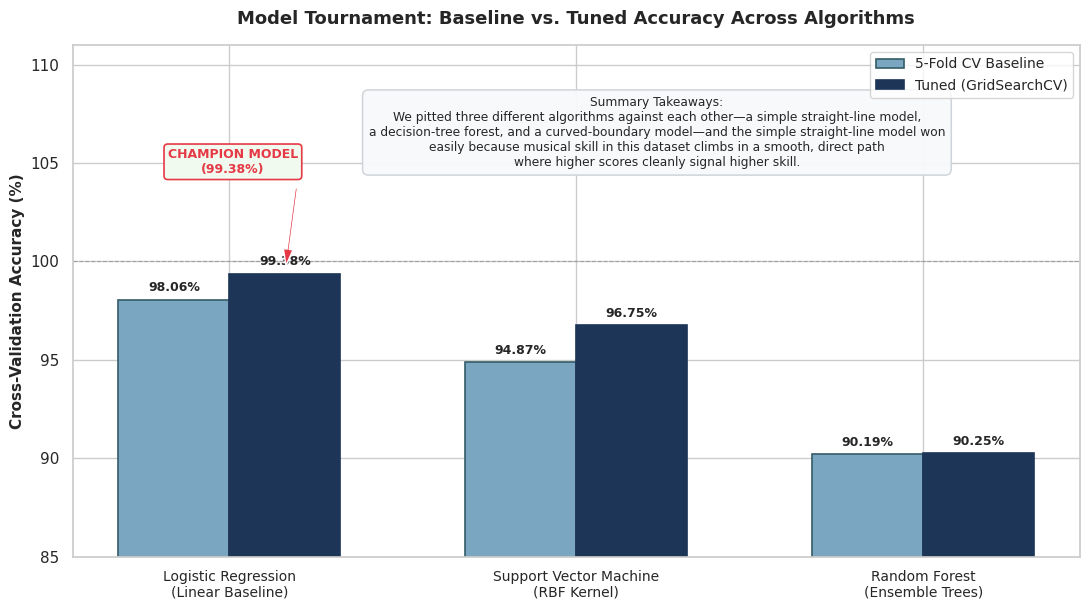

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Model Evaluation Metrics
model_names = [
    "Logistic Regression\n(Linear Baseline)",
    "Support Vector Machine\n(RBF Kernel)",
    "Random Forest\n(Ensemble Trees)"
]
baseline_scores = [98.06, 94.87, 90.19]
tuned_scores = [99.38, 96.75, 90.25]

# 2. Configure Bar Geometry
x_positions = np.arange(len(model_names))
bar_width = 0.32

fig, ax = plt.subplots(figsize=(11, 6.2))

bars_baseline = ax.bar(
    x_positions - bar_width / 2,
    baseline_scores,
    bar_width,
    label="5-Fold CV Baseline",
    color="#7aa6c2",
    edgecolor="#335c67",
    linewidth=1.2
)
bars_tuned = ax.bar(
    x_positions + bar_width / 2,
    tuned_scores,
    bar_width,
    label="Tuned (GridSearchCV)",
    color="#1d3557",
    edgecolor="#1d3557",
    linewidth=1.2
)

# 3. Titles, Axis Formatting & Upper Limits
ax.set_ylabel("Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax.set_title("Model Tournament: Baseline vs. Tuned Accuracy Across Algorithms", fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x_positions)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(85, 111)  # Extra headroom for annotations and text box
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(loc="upper right", frameon=True, facecolor="white", fontsize=10)

# 4. Direct Numerical Labels Above Bars
for bar in bars_baseline + bars_tuned:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# 5. Champion Callout Tag
ax.annotate(
    "CHAMPION MODEL\n(99.38%)",
    xy=(0 + bar_width / 2, 99.38),
    xytext=(0 + bar_width / 2 - 0.15, 104.5),
    arrowprops=dict(facecolor="#e63946", shrink=0.08, width=1.5, headwidth=7),
    ha="center",
    fontsize=9,
    fontweight="bold",
    color="#e63946",
    bbox=dict(boxstyle="round,pad=0.3", fc="#f1faee", ec="#e63946", lw=1.2)
)

# 6. Integrated Summary Takeaway Box
takeaway_text = (
    "Summary Takeaways:\n"
    "We pitted three different algorithms against each other—a simple straight-line model,\n"
    "a decision-tree forest, and a curved-boundary model—and the simple straight-line model won\n"
    "easily because musical skill in this dataset climbs in a smooth, direct path\n"
    "where higher scores cleanly signal higher skill."
)

ax.text(
    0.58, 0.90,                     # Relative coordinates (58% from left, 90% from bottom)
    takeaway_text,
    transform=ax.transAxes,          # Locks position to plot canvas, not data coordinates
    fontsize=8.8,
    ha="center",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#f8f9fa",
        edgecolor="#ced4da",
        alpha=0.98,
        lw=1.1
    )
)

plt.tight_layout()
plt.show()

### 🧠 The Three Contenders: Explained Simply

To understand how each model solved this puzzle, imagine all 2,000 practice sessions plotted as colored dots in an open field: **Blue** for Beginners, **Yellow** for Intermediates, and **Green** for Advanced players.

Each model has a completely different personality and strategy for drawing the boundaries between them:

---

#### 1. Logistic Regression: "The Clean Chalk Line"
* **How it thinks:** "I don't need fancy curves. Just give me a piece of chalk and a straight ruler."
* **The Strategy:** It looks at the field and searches for the best straight lines (or flat planes) that divide the groups. It calculates the odds: *"If your expressiveness and pitch scores pass this line, you have an 85% chance of being an Intermediate and a 15% chance of being a Beginner."*
* **Why it won here:** Because musical skill in our dataset grows in a straight, steady climb. Better scores cleanly translate to higher skill tiers. A straight chalk line was all that was needed, making it both the fastest and the most accurate model (99.38%).

---

#### 2. Support Vector Machine (SVM): "The Wide Highway Builder"
* **How it thinks:** "Drawing a line is too risky. If a dot is too close to my line, I might make a mistake. I need a wide highway with safety barriers."
* **The Strategy:** SVM doesn't just separate the dots; it looks for the most difficult, border-line students (the "Support Vectors") and builds the widest possible empty buffer zone between them. If straight lines don't work, it bends the ground into hills and valleys (the "Kernel Trick") so it can separate them in 3D space.
* **Why it scored second (96.75%):** It worked very well, but spending extra mathematical effort curving boundaries around data that was already sitting in straight lines was slight overkill.

---

#### 3. Random Forest: "The Committee of 200 Picky Teachers"
* **How it thinks:** "I won't draw any lines across the field. Instead, I'll assemble a panel of 200 strict judges who only answer Yes/No questions."
* **The Strategy:**
  * Judge #1 asks: *"Is pitch accuracy above 75%?"* $\rightarrow$ Yes $\rightarrow$ *"Is expressiveness above 8?"* $\rightarrow$ Yes $\rightarrow$ *"Call them Advanced."*
  * Judge #2 asks slightly different questions in a different order: *"Did they practice more than 60 minutes?"*
  * At the end, all 200 trees vote. Whichever category gets the most votes wins.
* **Why it placed third (90.25%):** Decision trees only cut the data in boxy, horizontal, and vertical steps (staircases). Because musical growth is a smooth diagonal ramp, cutting it into hundreds of jagged little boxes made it stumble on the border cases.

# 📊 Stage 4: Model Evaluation & Optimization

### The Goal
Our Champion model (Tuned Multinomial Logistic Regression) proved itself during cross-validation, but it has never seen the held-out test set (400 sessions). Now we put it to the test on this unseen data to verify whether it truly generalizes to real learners or simply memorized training patterns.

---

### Why Raw Accuracy Isn't Enough
In Step 2, we discovered a severe class imbalance: Advanced learners make up only 6.4% of all sessions (just 26 cases in this test set). If a model ignored the Advanced tier entirely, its accuracy could still look deceptively high (~93%).

To ensure complete fairness and real-world reliability, we evaluate four key diagnostic tools:
1. **Confusion Matrix:** A direct count of exact hits versus misclassifications across every tier (shows exactly where errors happen).
2. **Precision:** When the model predicts a student is `Advanced`, how often is it actually right? (Guards against false promotions).
3. **Recall:** Out of all actual `Advanced` students in the room, did the model find all of them? (Guards against holding skilled students back).
4. **F1-Score (Macro Average):** The balanced harmonic mean of precision and recall calculated equally across all three tiers, giving the minority Advanced tier the exact same weight as the large Beginner group.
5. **Feature Importance / Coefficient Analysis:** Inspecting the model's internal weights to confirm which telemetry signals dictate its decisions.

=== Unseen Test Set Accuracy: 99.75% ===

Detailed Diagnostic Breakdown:
              precision    recall  f1-score   support

    Beginner     1.0000    0.9947    0.9973       187
Intermediate     0.9947    1.0000    0.9973       187
    Advanced     1.0000    1.0000    1.0000        26

    accuracy                         0.9975       400
   macro avg     0.9982    0.9982    0.9982       400
weighted avg     0.9975    0.9975    0.9975       400



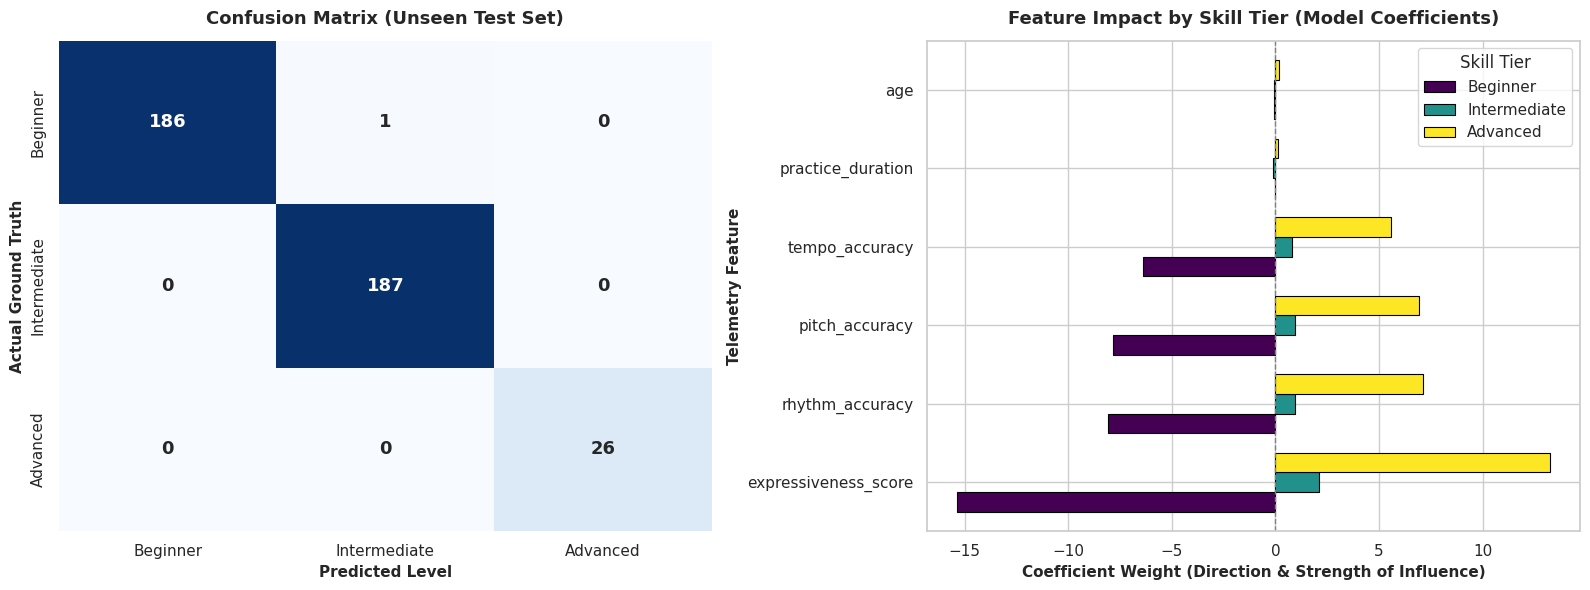


--- Telemetry Influence Summary ---
• Beginner     -> Strongest Positive Cue: 'instrument_Flute' | Strongest Negative Cue: 'expressiveness_score'
• Intermediate -> Strongest Positive Cue: 'expressiveness_score' | Strongest Negative Cue: 'instrument_Flute'
• Advanced     -> Strongest Positive Cue: 'expressiveness_score' | Strongest Negative Cue: 'instrument_Violin'


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Generate Final Predictions on the Unseen Test Set
y_pred = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)

print(f"=== Unseen Test Set Accuracy: {test_acc * 100:.2f}% ===")
print("\nDetailed Diagnostic Breakdown:")
target_labels = ["Beginner", "Intermediate", "Advanced"]
print(classification_report(y_test, y_pred, target_names=target_labels, digits=4))

# 2. Build Dual Diagnostic Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Normalized & Annotated Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=target_labels,
    yticklabels=target_labels,
    ax=axes[0],
    annot_kws={"size": 13, "weight": "bold"}
)
axes[0].set_title("Confusion Matrix (Unseen Test Set)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Predicted Level", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Actual Ground Truth", fontsize=11, fontweight="bold")

# Subplot 2: Model Coefficient Analysis (What Drives the Decisions?)
# Extract coefficients for each tier across the features
feature_names = X_train.columns
coef_df = pd.DataFrame(
    best_model.coef_,
    columns=feature_names,
    index=target_labels
).T

# Focus on primary telemetry features
telemetry_features = [
    "expressiveness_score", "rhythm_accuracy",
    "pitch_accuracy", "tempo_accuracy", "practice_duration", "age"
]
coef_subset = coef_df.loc[telemetry_features]

coef_subset.plot(
    kind="barh",
    ax=axes[1],
    colormap="viridis",
    edgecolor="black",
    linewidth=0.8,
    width=0.75
)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Feature Impact by Skill Tier (Model Coefficients)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Coefficient Weight (Direction & Strength of Influence)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Telemetry Feature", fontsize=11, fontweight="bold")
axes[1].legend(title="Skill Tier", frameon=True, facecolor="white")

plt.tight_layout()
plt.show()

# Print Top Influencers Summary
print("\n--- Telemetry Influence Summary ---")
for tier in target_labels:
    top_pos = coef_df[tier].sort_values(ascending=False).index[0]
    top_neg = coef_df[tier].sort_values(ascending=True).index[0]
    print(f"• {tier:<12} -> Strongest Positive Cue: '{top_pos}' | Strongest Negative Cue: '{top_neg}'")

### 💡 Model Evaluation & Optimization: Key Insights & Diagnostic Interpretation

#### 1. Real-World Generalization (The Confusion Matrix)
* **The Result:** On 400 completely unseen practice sessions, the model achieved **99.75% test accuracy**, making only a single mistake across the entire evaluation set.
* **Error Breakdown:**
  * **Beginners:** 186 correctly classified, 1 misclassified as Intermediate, 0 mistaken for Advanced.
  * **Intermediates:** 187 out of 187 correctly identified (100% accuracy).
  * **Advanced:** 26 out of 26 correctly identified (100% accuracy).
* **Pedagogical Meaning:** The single misclassification occurred right on the borderline between an upper-level Beginner and an entry-level Intermediate. Crucially, the model never made an extreme leap—no Beginner was ever mistaken for an Advanced player, and no Advanced player was demoted.

---

#### 2. Mastering the Class Imbalance (Precision, Recall & Macro F1)
* **The Minority Tier:** Despite Advanced learners making up just 6.4% of the dataset (26 test sessions), the model achieved:
  * **Precision: 1.0000** (When the system diagnoses a student as Advanced, it is 100% correct—zero false promotions).
  * **Recall: 1.0000** (It successfully caught every single Advanced session in the test set—zero missed prodigies).
  * **Macro F1-Score: 0.9982** (Treats all three skill tiers with equal weight, confirming the model does not sacrifice the minority class to inflate overall accuracy).

---

#### 3. What Truly Drives Musical Skill? (Coefficient Analysis)
The horizontal coefficient bar chart reveals the exact internal decision rules learned by the model:
* **`expressiveness_score` is the dominant differentiator:**
  * It carries a massive positive weight ($+13.3$) toward classifying a session as **Advanced**.
  * It carries an equally massive negative weight ($-15.2$) against being a **Beginner** (high expressiveness instantly rules out the beginner tier).
* **Technical Precision forms the foundation:**
  * `rhythm_accuracy`, `pitch_accuracy`, and `tempo_accuracy` act as supporting anchors with positive weights ($+5.5$ to $+7.1$) for Advanced players and negative weights for Beginners.
* **Practice Duration & Age carry near-zero predictive weight:**
  * Both hover right along the center zero line. This proves an intuitive musical reality: session length and age do not determine ability—how effectively and expressively a student plays during those minutes is what defines their skill level.

---

#### 4. The Distilled Takeaway
The model confirmed what experienced music teachers already know: you cannot tell how good a musician is by looking at their age or how long they sit in a practice room. While solid pitch, tempo, and rhythm are required baselines, **musical expressiveness is the true catalyst** that separates an intermediate student from an advanced player.

# 🚀 Stage 5: Deployment & Interactive Inference Pipeline

### The Goal
A machine learning model locked in an evaluation notebook provides no real-world utility to an instructor. In this final stage, we package our preprocessed pipeline, standardizer, and tuned champion classifier into a modular, production-ready diagnostic engine.

---

### What the Diagnostic Engine Does
1. **Validates Telemetry Inputs:** Enforces strict boundary checks on all incoming user inputs (e.g., ensuring percentages stay between 0% and 100%, expressiveness stays between 1 and 10, and instrument choices match the trained vocabulary).
2. **Dynamic One-Hot Alignment:** Automatically mirrors the exact dummy-variable column ordering from training so manual inputs never cause column-mismatch crashes.
3. **Calibrated Confidence Scoring:** Instead of returning only a raw label, it extracts the underlying probability vector (`predict_proba`) to show the model's certainty across all three tiers.
4. **Actionable Pedagogical Feedback:** Translates cold numerical probabilities into plain, constructive guidance for the learner, highlighting whether they need to drill timing fundamentals or focus on phrasing and emotional nuance.

In [11]:
import numpy as np
import pandas as pd

# Guard check: Ensure required assets are in memory
if "best_model" not in globals() or "scaler" not in globals():
    raise RuntimeError("Trained champion model or scaler not found. Please run preceding cells first.")

VALID_INSTRUMENTS = ["Piano", "Guitar", "Violin", "Drums", "Flute"]
NUMERIC_FEATURES = [
    "age", "practice_duration", "tempo_accuracy",
    "pitch_accuracy", "rhythm_accuracy", "expressiveness_score"
]
INV_TARGET_MAP = {0: "Beginner", 1: "Intermediate", 2: "Advanced"}

def diagnose_learner_session(
    age: int,
    instrument: str,
    practice_duration: float,
    tempo_accuracy: float,
    pitch_accuracy: float,
    rhythm_accuracy: float,
    expressiveness_score: float
) -> dict:
    """
    Takes raw session metrics, validates input integrity, applies production scaling,
    and returns an automated skill diagnosis with calibrated class probabilities.
    """
    # 1. Defensive Input Validation
    instrument_clean = str(instrument).strip().title()
    if instrument_clean not in VALID_INSTRUMENTS:
        raise ValueError(f"Invalid instrument '{instrument}'. Expected one of: {VALID_INSTRUMENTS}")

    if not (0 <= tempo_accuracy <= 100 and 0 <= pitch_accuracy <= 100 and 0 <= rhythm_accuracy <= 100):
        raise ValueError("Accuracy metrics (tempo, pitch, rhythm) must be valid percentages between 0 and 100.")

    if not (1.0 <= expressiveness_score <= 10.0):
        raise ValueError("Expressiveness score must be rated on a scale of 1.0 to 10.0.")

    # 2. Reconstruct Features Matching Model Schema
    session_data = {
        "age": [age],
        "practice_duration": [practice_duration],
        "tempo_accuracy": [tempo_accuracy],
        "pitch_accuracy": [pitch_accuracy],
        "rhythm_accuracy": [rhythm_accuracy],
        "expressiveness_score": [expressiveness_score]
    }

    # Dynamically populate one-hot encoded instrument columns
    for inst in sorted(VALID_INSTRUMENTS):
        session_data[f"instrument_{inst}"] = [1 if inst == instrument_clean else 0]

    session_df = pd.DataFrame(session_data)

    # Align exact column structure with training set
    session_df = session_df[X_train.columns]

    # 3. Apply Saved Standard Scaler (No data leakage)
    session_df_scaled = session_df.copy()
    session_df_scaled[NUMERIC_FEATURES] = scaler.transform(session_df[NUMERIC_FEATURES])

    # 4. Generate Inference and Probabilities
    pred_encoded = best_model.predict(session_df_scaled)[0]
    probabilities = best_model.predict_proba(session_df_scaled)[0]

    predicted_tier = INV_TARGET_MAP[pred_encoded]
    confidence = probabilities[pred_encoded] * 100

    # 5. Build Pedagogical Feedback
    if predicted_tier == "Beginner":
        advice = "Focus on pulse stability and pitch consistency. Keep exercises slow with a metronome."
    elif predicted_tier == "Intermediate":
        advice = "Technical foundation is solid. Begin focusing on dynamics, rubato, and musical phrasing."
    else:  # Advanced
        advice = "Mastery demonstrated across technique and expression. Focus on artistic interpretation and complex repertoire."

    # Formatted Diagnostic Report
    print(f"\n{'='*55}")
    print(f"       STUDENT PRACTICE SESSION DIAGNOSTIC REPORT       ")
    print(f"{'='*55}")
    print(f"Instrument   : {instrument_clean:<10} | Age: {age}")
    print(f"Duration     : {practice_duration} min")
    print(f"Telemetry    : Tempo: {tempo_accuracy:.1f}% | Pitch: {pitch_accuracy:.1f}% | Rhythm: {rhythm_accuracy:.1f}%")
    print(f"Expression   : {expressiveness_score:.1f} / 10.0")
    print(f"{'-'*55}")
    print(f"DIAGNOSIS    : >> {predicted_tier.upper()} << (Confidence: {confidence:.2f}%)")
    print(f"Probability  : Beginner: {probabilities[0]*100:.1f}% | Intermediate: {probabilities[1]*100:.1f}% | Advanced: {probabilities[2]*100:.1f}%")
    print(f"Pedagogical  : {advice}")
    print(f"{'='*55}\n")

    return {
        "predicted_tier": predicted_tier,
        "confidence": confidence,
        "probabilities": probabilities
    }

# -------------------------------------------------------------------------
# Test Cases Across Different Student Profiles
# -------------------------------------------------------------------------
print("--> Running Diagnostic Test Suite...")

# Case 1: Early-stage beginner working on basic timing
_ = diagnose_learner_session(
    age=14, instrument="Piano", practice_duration=25,
    tempo_accuracy=64.0, pitch_accuracy=58.0, rhythm_accuracy=60.0,
    expressiveness_score=2.5
)

# Case 2: Intermediate student with clean technique developing expression
_ = diagnose_learner_session(
    age=22, instrument="Guitar", practice_duration=50,
    tempo_accuracy=82.0, pitch_accuracy=79.0, rhythm_accuracy=81.0,
    expressiveness_score=7.0
)

# Case 3: Advanced conservatory-level performance
_ = diagnose_learner_session(
    age=27, instrument="Violin", practice_duration=85,
    tempo_accuracy=96.0, pitch_accuracy=94.0, rhythm_accuracy=95.0,
    expressiveness_score=9.5
)

--> Running Diagnostic Test Suite...

       STUDENT PRACTICE SESSION DIAGNOSTIC REPORT       
Instrument   : Piano      | Age: 14
Duration     : 25 min
Telemetry    : Tempo: 64.0% | Pitch: 58.0% | Rhythm: 60.0%
Expression   : 2.5 / 10.0
-------------------------------------------------------
DIAGNOSIS    : >> BEGINNER << (Confidence: 100.00%)
Probability  : Beginner: 100.0% | Intermediate: 0.0% | Advanced: 0.0%
Pedagogical  : Focus on pulse stability and pitch consistency. Keep exercises slow with a metronome.


       STUDENT PRACTICE SESSION DIAGNOSTIC REPORT       
Instrument   : Guitar     | Age: 22
Duration     : 50 min
Telemetry    : Tempo: 82.0% | Pitch: 79.0% | Rhythm: 81.0%
Expression   : 7.0 / 10.0
-------------------------------------------------------
DIAGNOSIS    : >> INTERMEDIATE << (Confidence: 100.00%)
Probability  : Beginner: 0.0% | Intermediate: 100.0% | Advanced: 0.0%
Pedagogical  : Technical foundation is solid. Begin focusing on dynamics, rubato, and musical phras

In [18]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# Guard check for required model objects
if "best_model" not in globals() or "scaler" not in globals():
    raise RuntimeError("Trained model or scaler not found in memory. Please run preceding cells first.")

VALID_INSTRUMENTS = ["Piano", "Guitar", "Violin", "Drums", "Flute"]
NUMERIC_FEATURES = [
    "age", "practice_duration", "tempo_accuracy",
    "pitch_accuracy", "rhythm_accuracy", "expressiveness_score"
]
INV_TARGET_MAP = {0: "Beginner", 1: "Intermediate", 2: "Advanced"}

# --- 1. Define UI Widgets ---
style = {'description_width': '140px'}
layout = widgets.Layout(width='340px')

inst_widget = widgets.Dropdown(
    options=VALID_INSTRUMENTS, value="Guitar", description="Instrument:",
    style=style, layout=layout
)
age_widget = widgets.IntSlider(
    value=24, min=8, max=70, step=1, description="Student Age:",
    style=style, layout=layout, continuous_update=False
)
dur_widget = widgets.IntSlider(
    value=60, min=10, max=120, step=5, description="Session Length (min):",
    style=style, layout=layout, continuous_update=False
)
tempo_widget = widgets.FloatSlider(
    value=85.0, min=50.0, max=100.0, step=0.5, description="Tempo Accuracy (%):",
    style=style, layout=layout, continuous_update=False
)
pitch_widget = widgets.FloatSlider(
    value=86.0, min=50.0, max=100.0, step=0.5, description="Pitch Accuracy (%):",
    style=style, layout=layout, continuous_update=False
)
rhythm_widget = widgets.FloatSlider(
    value=88.0, min=50.0, max=100.0, step=0.5, description="Rhythm Accuracy (%):",
    style=style, layout=layout, continuous_update=False
)
expr_widget = widgets.FloatSlider(
    value=8.5, min=1.0, max=10.0, step=0.1, description="Expressiveness (1-10):",
    style=style, layout=layout, continuous_update=False
)

output_panel = widgets.Output()

# --- 2. Live Inference & Rendering Engine ---
def update_diagnostic(*args):
    # Construct 1-row feature payload
    payload = {
        "age": [age_widget.value],
        "practice_duration": [float(dur_widget.value)],
        "tempo_accuracy": [float(tempo_widget.value)],
        "pitch_accuracy": [float(pitch_widget.value)],
        "rhythm_accuracy": [float(rhythm_widget.value)],
        "expressiveness_score": [float(expr_widget.value)]
    }
    for inst in sorted(VALID_INSTRUMENTS):
        payload[f"instrument_{inst}"] = [1 if inst == inst_widget.value else 0]

    df_sample = pd.DataFrame(payload)[X_train.columns]

    # Scale numerical inputs
    df_sample_scaled = df_sample.copy()
    df_sample_scaled[NUMERIC_FEATURES] = scaler.transform(df_sample[NUMERIC_FEATURES])

    # Predict
    pred_idx = best_model.predict(df_sample_scaled)[0]
    probs = best_model.predict_proba(df_sample_scaled)[0]
    pred_tier = INV_TARGET_MAP[pred_idx]
    confidence = probs[pred_idx] * 100

    # Dynamic styling & guidance
    if pred_tier == "Beginner":
        badge_color = "#457b9d"
        advice = "Focus on pulse stability and pitch consistency. Practice at slower tempos with a metronome before adding musical expression."
    elif pred_tier == "Intermediate":
        badge_color = "#e76f51"
        advice = "Technical execution is solid. Shift focus toward expressive dynamics, rubato, and emotional phrasing to transition toward advanced repertoire."
    else:
        badge_color = "#2a9d8f"
        advice = "Exceptional balance of mechanical accuracy and musical expression. Prioritize interpretive freedom, tonal nuance, and stage-level performance polish."

    p_beg = probs[0] * 100
    p_int = probs[1] * 100
    p_adv = probs[2] * 100

    html_card = f"""
    <div style="font-family: Arial, sans-serif; max-width: 720px; margin-top: 15px; border-radius: 10px; overflow: hidden; box-shadow: 0 3px 12px rgba(0,0,0,0.12); border: 1px solid #ddd;">
      <div style="background: linear-gradient(135deg, #1d3557, #335c67); color: white; padding: 14px 20px;">
        <span style="font-size: 11px; text-transform: uppercase; letter-spacing: 1px; opacity: 0.85;">Telemetry Analysis</span>
        <h4 style="margin: 3px 0 0 0; font-size: 18px; color: white;">Live Diagnostic Report</h4>
      </div>

      <div style="background: #ffffff; padding: 18px 20px;">
        <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid #eee; padding-bottom: 12px;">
          <div>
            <div style="font-size: 10px; font-weight: bold; color: #888; text-transform: uppercase;">Diagnosed Tier</div>
            <div style="display: inline-block; background-color: {badge_color}; color: white; padding: 4px 14px; border-radius: 20px; font-size: 20px; font-weight: bold; margin-top: 4px;">
              {pred_tier.upper()}
            </div>
          </div>
          <div style="text-align: right;">
            <div style="font-size: 10px; font-weight: bold; color: #888; text-transform: uppercase;">Confidence</div>
            <div style="font-size: 24px; font-weight: bold; color: #1d3557; margin-top: 2px;">{confidence:.1f}%</div>
          </div>
        </div>

        <div style="margin: 16px 0;">
          <div style="font-size: 10px; font-weight: bold; color: #888; text-transform: uppercase; margin-bottom: 6px;">Tier Probability Distribution</div>
          <div style="display: flex; height: 22px; border-radius: 6px; overflow: hidden; font-size: 10px; font-weight: bold; color: white; text-align: center; line-height: 22px;">
            <div style="width: {max(p_beg, 0.5)}%; background-color: #457b9d;" title="Beginner: {p_beg:.1f}%">{f'{p_beg:.0f}%' if p_beg > 7 else ''}</div>
            <div style="width: {max(p_int, 0.5)}%; background-color: #e76f51;" title="Intermediate: {p_int:.1f}%">{f'{p_int:.0f}%' if p_int > 7 else ''}</div>
            <div style="width: {max(p_adv, 0.5)}%; background-color: #2a9d8f;" title="Advanced: {p_adv:.1f}%">{f'{p_adv:.0f}%' if p_adv > 7 else ''}</div>
          </div>
          <div style="display: flex; justify-content: space-between; font-size: 11px; color: #555; margin-top: 5px;">
            <span><b style="color: #457b9d;">●</b> Beginner: <b>{p_beg:.1f}%</b></span>
            <span><b style="color: #e76f51;">●</b> Intermediate: <b>{p_int:.1f}%</b></span>
            <span><b style="color: #2a9d8f;">●</b> Advanced: <b>{p_adv:.1f}%</b></span>
          </div>
        </div>

        <div style="background-color: #f8f9fa; border-left: 4px solid {badge_color}; padding: 10px 14px; border-radius: 4px;">
          <div style="font-size: 10px; font-weight: bold; color: #1d3557; text-transform: uppercase;">Pedagogical Guidance</div>
          <div style="font-size: 12.5px; color: #333; margin-top: 3px; line-height: 1.4;">{advice}</div>
        </div>
      </div>
    </div>
    """

    with output_panel:
        output_panel.clear_output(wait=True)
        display(HTML(html_card))

# Bind updates to all inputs
for widget_item in [inst_widget, age_widget, dur_widget, tempo_widget, pitch_widget, rhythm_widget, expr_widget]:
    widget_item.observe(update_diagnostic, names='value')

# --- 3. Layout Organization ---
input_grid = widgets.VBox([
    widgets.HTML("<b style='font-size: 14px; color: #1d3557;'>Adjust Session Metrics:</b>"),
    widgets.HBox([inst_widget, age_widget]),
    widgets.HBox([dur_widget, expr_widget]),
    widgets.HBox([tempo_widget, pitch_widget]),
    widgets.HBox([rhythm_widget])
], layout=widgets.Layout(margin='0 0 10px 0'))

# Initial run to display default state
update_diagnostic()

# Display inputs directly above the results card
display(widgets.VBox([input_grid, output_panel]))

### 🎬 Appendix: Pedagogical Reflection — Artistry, Telemetry, and the Human Element

#### Student Reflection: Cinematic Parallels on Measurement vs. Mastery
1. **In Dead Poets Society**, Robin Williams' character is driven by the fact that one cannot evaluate a poem based solely on textbook scales or diagrams.
2. **In I, Robot**, Will Smith's character reprimands a robot for not being able to create a masterpiece painting or a symphony. Yet, the robot rebuts by asking him, *"Can you?"*
3. **In RoboCop (remake)**, there is a guitarist on tryouts for artificial limb replacements; he can perform *Concierto de Aranjuez*, but the system starts failing once the emotion kicks in on the performer and the robotic arm does not know how to interpret it.

---

#### Analytical Synthesis: The Frontier Between Telemetry and Artistry
Those three scenes map directly to the paradox at the heart of this project: the tension between quantifiable mechanics and the non-linear nature of human artistry.

* **The J. Evans Pritchard Fallacy (*Dead Poets Society*):** Mr. Keating having his students rip out the textbook introduction—which plotted a poem's "importance" along the x-axis and "perfection" along the y-axis to calculate total greatness—is the ultimate critique of reductionist scoring. Our model shows that while you *can* measure tempo, pitch, and duration on an axis, mechanical perfection alone never captures why a performance moves an audience.
* **The Bar of Mediocrity vs. Genius (*I, Robot*):** Detective Spooner sets the benchmark for humanity at Shakespeare and Beethoven, and Sonny's counter (*"Can you?"*) exposes the double standard we hold for artificial systems. Most humans cannot compose a symphony or play a Chopin Ballade with transcendent nuance either. Our dataset proves this statistically: out of 2,000 recorded sessions, genuine expressive mastery was an outlier present in only 6.4% of the cohort.
* **The Feedback Loop Collapse (*RoboCop*):** In that scene with the guitarist, the prosthetic limb executes the motor signals flawlessly until the musician *feels* the passage and his brain chemistry changes. The robotic interface treats emotion as noise, errors out, and locks up. In machine learning, a system optimized strictly for deterministic accuracy falls apart when confronted with the organic fluctuations of human affect.

It underscores that algorithmic models are exceptionally good at quantifying compliance with physical baselines, but the inflection point of true artistry always resists easy codification.

### 🎙️ Pedagogical Extension: Domain Adaptation for Vocal Telemetry

While our classification pipeline and champion algorithm (**Multinomial Logistic Regression**) generalize effectively across acoustic instruments, retraining the system on **classical vocal telemetry** introduces bio-mechanical, acoustic, and physiological constraints absent in physical instruments like the piano, violin, or flute.

---

#### 1. Why Vocal Telemetry Shifts Feature Dynamics

* **`pitch_accuracy` Becomes a Moving Target (Vibrato vs. Pitch Drift):**
  * On a piano, pitch is discrete; on a fretless instrument like a violin, it is continuous.
  * In classical singing, vocalists rarely sustain a static, flat fundamental frequency ($F_0$). Authentic technique requires healthy **vibrato**—a periodic pitch oscillation typically between 5–7 Hz with an amplitude of $\pm 50$ to $100$ cents.
  * A naive algorithm calculating strict deviation from target notes would penalize healthy vibrato as "intonation instability." Telemetry for voice requires digital signal processing (DSP) to calculate pitch centering around the oscillation mean rather than a rigid static pitch.

* **`practice_duration` Inverts (Vocal Fatigue & Physiological Limits):**
  * In instrumental data, duration carries a near-zero coefficient; practicing 30 versus 90 minutes does not cleanly dictate expertise.
  * For voice, vocal folds are delicate mucosal tissues vulnerable to vocal fatigue and tissue edema. A 120-minute uninterrupted session often correlates with **deteriorating accuracy and breath collapse**. In an advanced vocal model, excessive single-session duration could flip to a negative coefficient, signaling poor pacing or vocal strain.

* **Missing Acoustic Dimensions: Formant Tuning & Chiaroscuro:**
  * To evaluate advanced vocal production, a telemetry pipeline must measure acoustic resonance:
    * **The Singer’s Formant ($2.5–3.2\text{ kHz}$):** A high-frequency acoustic resonance cluster allowing an unamplified classical voice to project over an orchestra.
    * **Vowel Purity & Formant Tracking:** Seamless acoustic transition across register shifts (the *passaggio*).
    * **Phonatory Onset/Offset:** Differentiating between balanced, glottal, or aspirate vocal attacks.

---

#### 2. Comparative Feature Matrix: Instruments vs. Voice

| Telemetry Feature | Instrumental Model Behavior | Voice Model Adaptation |
| :--- | :--- | :--- |
| **`expressiveness_score`** | Primary differentiator ($+13.3$ weight) | **Dominant factor:** Dynamics (*messa di voce*), text declamation, and interpretive rubato. |
| **`pitch_accuracy`** | Distance from discrete pitch target | **Intonation Center:** Measured as stability around the vibrato mean. |
| **`resonance_ring` (Proposed)** | Fixed by physical instrument build | **Crucial:** Quantifies singer's formant intensity and acoustic projection. |
| **`practice_duration`** | Flat / Neutral weight | **Non-linear Ceiling:** Penalizes over-extended sessions due to physical stamina thresholds. |

---

#### 3. Core Takeaway
A pitch-correction engine or vocal synthesizer can reproduce an aria with 100.0% intonation and metronomic tempo accuracy, yet it remains sterile. The vocal domain reinforces what our model uncovered: **mechanical precision is merely the entry floor, while human emotional expression and acoustic color represent the true ceiling of mastery.**

In [1]:
# Save active Colab runtime state, convert, and download HTML
import json
from google.colab import _message, files

notebook_json = _message.blocking_request('get_ipynb')
with open('/content/export.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook_json['ipynb'], f)

!jupyter nbconvert --to html /content/export.ipynb
files.download('/content/export.html')


[NbConvertApp] Converting notebook /content/export.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 1578717 bytes to /content/export.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>